#Importing Dependencies

In [312]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score,confusion_matrix


#Data Collection and Analysis

In [283]:
#loading dataset
diabetes_dataset=pd.read_csv("/content/diabetes (1).csv")

In [284]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [285]:
diabetes_dataset.shape

(768, 9)

In [286]:
#getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [287]:
#counting the outcome of diabetes
diabetes_dataset["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-diabetic

1 --> Diabetic

In [288]:
#Checking Missing values
diabetes_dataset.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [289]:
diabetes_dataset.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [290]:
#handling imbalance data using undersampling
non_diabetic=diabetes_dataset[diabetes_dataset.Outcome==0]
diabetic=diabetes_dataset[diabetes_dataset.Outcome==1]

In [291]:
non__diabetic_sample=non_diabetic.sample(n=268)

In [292]:
#concatenate two dataframes
new_dataset=pd.concat([non__diabetic_sample,diabetic],axis=0)

In [293]:
new_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
532,1,86,66,52,65,41.3,0.917,29,0
139,5,105,72,29,325,36.9,0.159,28,0
51,1,101,50,15,36,24.2,0.526,26,0
101,1,151,60,0,0,26.1,0.179,22,0
639,1,100,74,12,46,19.5,0.149,28,0


In [294]:
new_dataset["Outcome"].value_counts()

,count
Outcome,
0,268
1,268


In [295]:
#Separating the data and labels
X=new_dataset.drop(columns="Outcome",axis=1)
Y=new_dataset["Outcome"]

In [296]:
print(X)
print(Y)

     Pregnancies  Glucose  BloodPressure  ...   BMI  DiabetesPedigreeFunction  Age
532            1       86             66  ...  41.3                     0.917   29
139            5      105             72  ...  36.9                     0.159   28
51             1      101             50  ...  24.2                     0.526   26
101            1      151             60  ...  26.1                     0.179   22
639            1      100             74  ...  19.5                     0.149   28
..           ...      ...            ...  ...   ...                       ...  ...
755            1      128             88  ...  36.5                     1.057   37
757            0      123             72  ...  36.3                     0.258   52
759            6      190             92  ...  35.5                     0.278   66
761            9      170             74  ...  44.0                     0.403   43
766            1      126             60  ...  30.1                     0.349   47

[53

In [297]:
#Train and Test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,stratify=Y,random_state=3)

In [298]:
print(X.shape,X_train.shape,X_test.shape)

(536, 8) (482, 8) (54, 8)


In [299]:
#standardize the data
scaler=StandardScaler()

In [300]:
X_train_scaled=scaler.fit_transform(X_train)

In [301]:
X_test_standardized=scaler.transform(X_test)

In [302]:
print(X_train_scaled.std())

1.0


#Model Training

In [303]:
classifier=svm.SVC(kernel="linear")

In [304]:
#training the support vector machine classifier
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

#Model Evaluation

In [305]:
#accuracy score on the training data
X_train_prediction=classifier.predict(X_train)
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print(training_data_accuracy)

0.7800829875518672


In [306]:
#accuracy score on the testing data
X_test_prediction=classifier.predict(X_test)
testing_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print(testing_data_accuracy)

0.8148148148148148


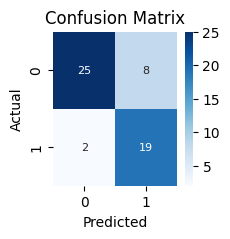

In [307]:
#confusion matrix on testing data
cm=confusion_matrix(X_test_prediction,Y_test)
plt.figure(figsize=(2,2))
sns.heatmap(cm,annot=True,annot_kws={"size":8},fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [311]:
input_data=(1,89,66,23,94,28.1,0.167,21)
feature_names=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
input_df=pd.DataFrame([input_data],columns=feature_names)
std_data=scaler.transform(input_df)
prediction=classifier.predict(std_data)
if (prediction[0]==0):
   print("Patient is non-diabetic")
else:
   print("Patient is diabetic")

Patient is non-diabetic
